# Building a GPT Model from Scratch

This notebook implements the **GPT-2 (124M) architecture** from the ground up using PyTorch.
It follows the standard decoder-only Transformer design and is organized so that every
component is defined **exactly once**, in the order it is used:

1. Configuration
2. Imports & tokenization
3. Layer Normalization
4. GELU activation
5. Feed-Forward network
6. Multi-Head (causal) Self-Attention
7. Transformer Block (assembling 3–6 with residual connections)
8. The full GPT model
9. Inspecting the model (parameter count & size)
10. Autoregressive text generation

> The goal is clarity: read it top-to-bottom and you have a complete, working GPT.


## 1. Model Configuration

All architectural hyper-parameters live in a single dictionary so they can be passed
around as one object. These values reproduce the smallest GPT-2 model (124M parameters).


In [ ]:
# GPT-2 "small" (124M parameters) configuration
GPT_CONFIG_124M = {
    "vocab_size":     50257,   # number of tokens in the GPT-2 BPE vocabulary
    "context_length": 1024,    # maximum sequence length the model can attend over
    "emb_dim":        768,     # embedding / hidden dimension
    "n_heads":        12,      # number of attention heads
    "n_layers":       12,      # number of stacked Transformer blocks
    "drop_rate":      0.1,     # dropout probability
    "qkv_bias":       False,   # whether Q/K/V linear layers use a bias term
}

## 2. Imports and Tokenization

We use PyTorch for the model and OpenAI's `tiktoken` for GPT-2 byte-pair-encoding (BPE)
tokenization. Below we tokenize two short sentences and stack them into a single batch
tensor of shape `(batch_size, num_tokens)` — the input format the model expects.


In [ ]:
import torch
import torch.nn as nn
import tiktoken

# Reproducibility
torch.manual_seed(123)

# GPT-2 uses byte-pair encoding (BPE)
tokenizer = tiktoken.get_encoding("gpt2")

# Encode a couple of sentences and stack them into one batch tensor.
batch = torch.stack([
    torch.tensor(tokenizer.encode("Every effort moves you")),
    torch.tensor(tokenizer.encode("Every day holds a")),
], dim=0)

print("Batch shape:", batch.shape)   # (2 sentences, 4 tokens each)
print(batch)

Batch shape: torch.Size([2, 4])
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


## 3. Layer Normalization

`LayerNorm` normalizes activations across the **embedding dimension** (not the batch),
so each token vector has zero mean and unit variance. Two learnable parameters —
`scale` (gamma) and `shift` (beta) — let the network undo or adjust the normalization
if that helps learning.

- `eps` is a small constant added for numerical stability (avoids divide-by-zero).
- `unbiased=False` uses the biased variance estimate (divide by N), matching the
  original GPT-2 implementation.


In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))   # learnable gain  (gamma)
        self.shift = nn.Parameter(torch.zeros(emb_dim))  # learnable bias  (beta)

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [ ]:
# Quick sanity check: after LayerNorm each row has ~0 mean and ~1 variance.
example = torch.randn(2, 5)
ln_out = LayerNorm(emb_dim=5)(example)
print("Mean:", ln_out.mean(dim=-1).detach())
print("Var :", ln_out.var(dim=-1, unbiased=False).detach())

Mean: tensor([-2.9802e-08,  0.0000e+00])
Var : tensor([1.0000, 1.0000])


## 4. GELU Activation

GPT-2 uses the **Gaussian Error Linear Unit (GELU)** instead of ReLU. GELU is smooth
(differentiable everywhere) and, unlike ReLU, allows small negative values to pass
through, which tends to improve training of deep Transformers. Below is the
`tanh` approximation used by GPT-2.


In [ ]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # tanh-based approximation of GELU (as used in the original GPT-2)
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

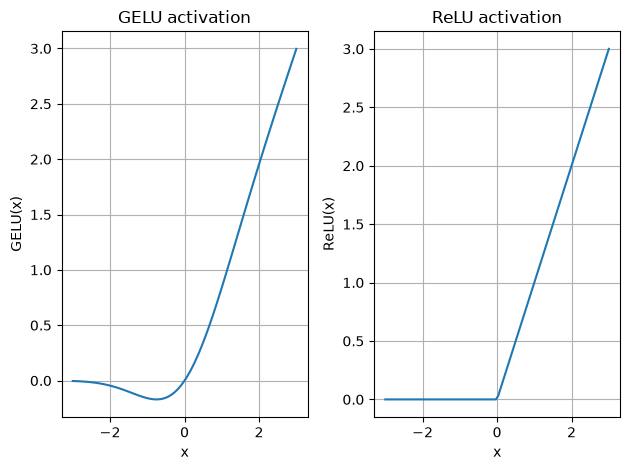

In [ ]:
# Visualize GELU vs. ReLU to see the smooth, non-zero-for-negatives behaviour.
import matplotlib.pyplot as plt

x = torch.linspace(-3, 3, 100)
for i, (fn, label) in enumerate([(GELU(), "GELU"), (nn.ReLU(), "ReLU")], start=1):
    plt.subplot(1, 2, i)
    plt.plot(x, fn(x))
    plt.title(f"{label} activation")
    plt.xlabel("x"); plt.ylabel(f"{label}(x)"); plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Feed-Forward Network

Each Transformer block contains a position-wise feed-forward network (FFN). It
**expands** the embedding dimension by 4x, applies GELU, then **contracts** it back.
This expansion gives the model extra capacity to transform each token representation
independently.


In [ ]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),   # expand  (768 -> 3072)
            GELU(),                                          # activation
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),   # contract (3072 -> 768)
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
# The FFN preserves shape: (batch, tokens, emb_dim) in -> same shape out.
ff_out = FeedForward(GPT_CONFIG_124M)(torch.rand(2, 3, 768))
print("FeedForward output shape:", ff_out.shape)

FeedForward output shape: torch.Size([2, 3, 768])


## 6. Multi-Head Causal Self-Attention

This is the core of the Transformer. Key ideas:

- **Q, K, V projections:** each token is linearly projected into query, key, and value
  vectors.
- **Multiple heads:** the projection is split into `num_heads` independent heads, each
  attending in a different subspace, then recombined.
- **Causal mask:** an upper-triangular mask sets attention to future tokens to `-inf`
  so a position can only attend to itself and earlier positions (required for
  autoregressive generation).
- **Scaled dot-product:** scores are divided by `sqrt(head_dim)` before softmax to keep
  gradients stable.

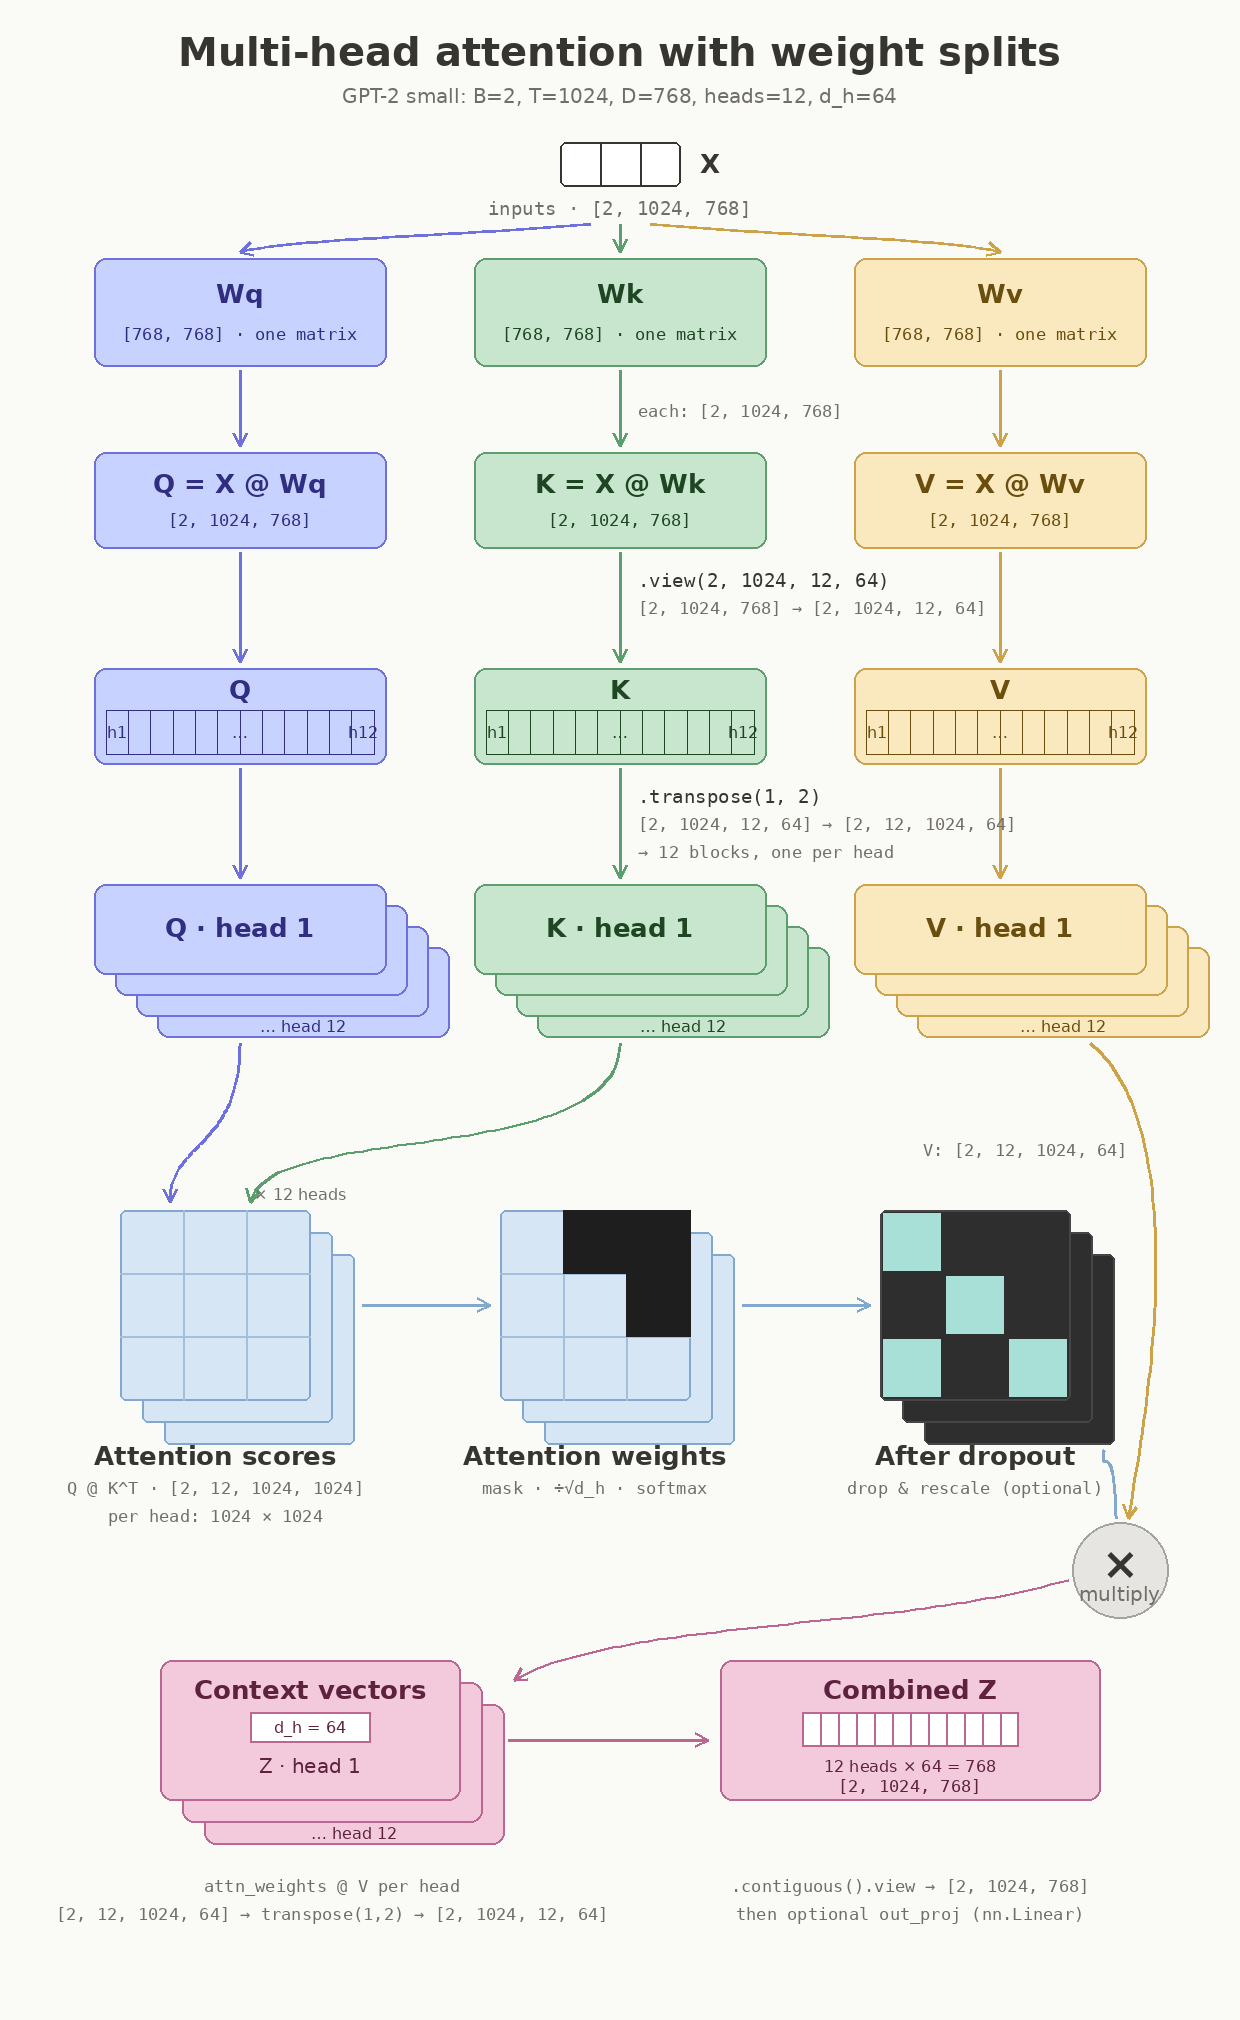

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads   # dimension handled by each head

        # Separate learnable projections for queries, keys, and values.
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)   # combines the heads back together
        self.dropout = nn.Dropout(dropout)

        # Causal mask (upper triangular, excluding the diagonal). Registered as a
        # buffer so it moves with the model to GPU/CPU but is not a trained parameter.
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # 1) Project inputs to Q, K, V  ->  (b, num_tokens, d_out)
        keys    = self.W_key(x)
        queries = self.W_query(x)
        values  = self.W_value(x)

        # 2) Split into heads: (b, num_tokens, num_heads, head_dim)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # 3) Move the head dimension forward: (b, num_heads, num_tokens, head_dim)
        keys    = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values  = values.transpose(1, 2)

        # 4) Scaled dot-product attention scores for every head.
        attn_scores = queries @ keys.transpose(2, 3)

        # 5) Apply the causal mask (block attention to future tokens).
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # 6) Softmax over the last dim, scaled by sqrt(head_dim), then dropout.
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 7) Weighted sum of values, then merge heads back to (b, num_tokens, d_out).
        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        # 8) Final output projection.
        return self.out_proj(context_vec)

## 7. The Transformer Block

A Transformer block wires the attention and feed-forward sub-layers together using the
**pre-LayerNorm** design and **residual (shortcut) connections**:

```
x -> LayerNorm -> Attention   -> Dropout -> (+ x)  ->  h
h -> LayerNorm -> FeedForward -> Dropout -> (+ h)  ->  out
```

Residual connections let gradients flow directly through the network, which is what
makes it possible to train very deep stacks of these blocks.


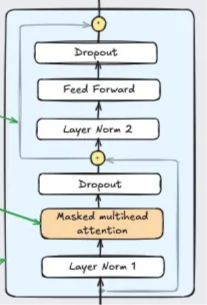

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # --- Attention sub-layer (with residual connection) ---
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        # --- Feed-forward sub-layer (with residual connection) ---
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

In [ ]:
# A single block preserves the input shape (batch, tokens, emb_dim).
block_out = TransformerBlock(GPT_CONFIG_124M)(torch.rand(2, 4, 768))
print("TransformerBlock output shape:", block_out.shape)

TransformerBlock output shape: torch.Size([2, 4, 768])


## 8. The Full GPT Model

Now we assemble the complete model:

1. **Token embeddings** map token IDs to vectors.
2. **Positional embeddings** add information about each token's position.
3. A stack of `n_layers` **Transformer blocks** processes the sequence.
4. A **final LayerNorm** stabilizes the output.
5. A linear **output head** projects each position back to vocabulary-sized `logits`.


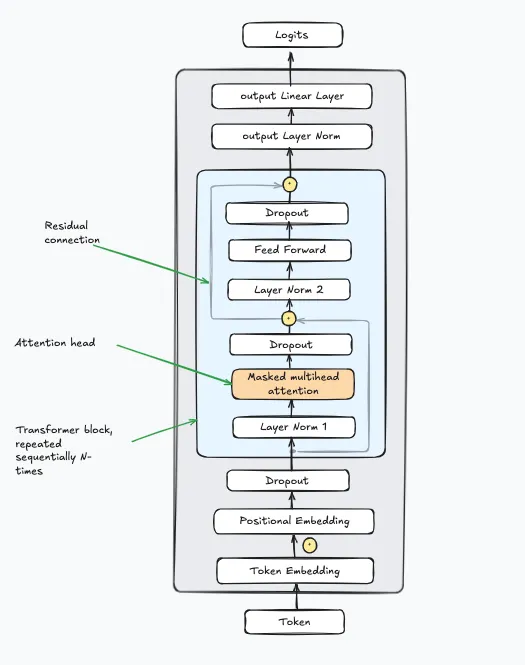


In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack of Transformer blocks.
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        # Output projection to vocabulary logits (no bias, as in GPT-2).
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)
        # Position ids [0, 1, ..., seq_len-1] on the same device as the input.
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds     # combine token + positional information
        x = self.drop_emb(x)
        x = self.trf_blocks(x)          # the bulk of the computation
        x = self.final_norm(x)
        logits = self.out_head(x)       # (batch, seq_len, vocab_size)
        return logits

In [ ]:
# Instantiate the model and run our tokenized batch through it.
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Input batch shape :", batch.shape)
print("Output logits shape:", logits.shape)   # (2, 4, 50257)

Input batch shape : torch.Size([2, 4])
Output logits shape: torch.Size([2, 4, 50257])


## 9. Inspecting the Model

Let's confirm the parameter count and estimate the memory footprint. The raw count is
larger than the advertised "124M" because GPT-2 **ties** the token-embedding and output
head weights (they share the same matrix); subtracting the output head gives the 124M figure.


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# With weight tying, the output head reuses the token-embedding weights.
params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Parameters with weight tying: {params_gpt2:,}")

# Rough memory footprint assuming float32 (4 bytes per parameter).
size_mb = total_params * 4 / (1024 * 1024)
print(f"Approx. model size: {size_mb:.2f} MB")

Total parameters: 163,009,536
Parameters with weight tying: 124,412,160
Approx. model size: 621.83 MB


## 10. Generating Text

Finally, we generate text **autoregressively**: repeatedly feed the current sequence to
the model, take the logits for the last position, pick the most likely next token
(greedy decoding via `argmax`), append it, and repeat.

> The model here is **untrained** (random weights), so the output will be gibberish —
> but it proves the full forward + generation pipeline works end to end.


In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    """Greedy autoregressive generation.

    idx: (batch, n_tokens) tensor of token IDs for the current context.
    """
    for _ in range(max_new_tokens):
        # Keep only the last `context_size` tokens (the model's window).
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        # Look only at the prediction for the final position.
        logits = logits[:, -1, :]                       # (batch, vocab_size)
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # greedy pick

        # Append the predicted token and continue.
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [ ]:
start_context = "Hello, I am"
encoded = torch.tensor(tokenizer.encode(start_context)).unsqueeze(0)  # add batch dim
print("Encoded input:", encoded.tolist())

model.eval()  # disable dropout for deterministic generation
out = generate_text_simple(
    model=model,
    idx=encoded,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"],
)

print("Generated token IDs:", out.tolist())
print("Decoded text:", tokenizer.decode(out.squeeze(0).tolist()))

Encoded input: [[15496, 11, 314, 716]]


Generated token IDs: [[15496, 11, 314, 716, 27018, 24086, 47843, 30961, 42348, 7267]]
Decoded text: Hello, I am Featureiman Byeswickattribute argue


## Summary

We built a complete GPT-2 (124M) model from scratch:

- **LayerNorm**, **GELU**, and **FeedForward** — each defined once.
- **Multi-head causal self-attention** with a registered causal mask.
- A **pre-LayerNorm Transformer block** with residual connections.
- The assembled **GPTModel** with token + positional embeddings and a tied output head.
- **Greedy text generation** demonstrating the end-to-end forward pass.

The next step (in a follow-up notebook) would be to **train** this model on real text so
the generated output becomes coherent.
